# Simulation 1 — analysis

Reads the per-rep CSVs written by [`experiment.ipynb`](experiment.ipynb) and
compares **ZQE** vs **gllvm** across the $p \times n$ sweep ($q=2$) on:

1. **Procrustes error** of the recovered loadings (headline accuracy);
2. **Bias & variance** of the recovered parameters (loadings and intercepts);
3. **Fit time**.

Loadings were Procrustes-rotated into the true gauge at write time, so estimates
are directly comparable to `true` element by element (see
[`results/DATA_DICTIONARY.md`](results/DATA_DICTIONARY.md)).

In [222]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

HERE = os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else os.getcwd()
if not os.path.exists(os.path.join(HERE, "sweep.py")):
    HERE = os.path.join(os.getcwd(), "simulations", "simulation_1")
sys.path.insert(0, HERE)
import sweep

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# Three arms (mirrors playground/poisson.ipynb): two ZQE encoders + R gllvm.
# Both ZQE arms use T=log1p and the same tiny ridge l2 = 0.001/n.
METHODS = ["zqe_pmap", "zqe_gmap", "gllvm"]
LABEL   = {"zqe_pmap": r"$Z_q$ (Poisson MAP)",
           "zqe_gmap": r"$Z_q$ (Gaussian log1p MAP)",
           "gllvm": "gllvm"}
MCOLOR  = {"zqe_pmap": "#1f77b4", "zqe_gmap": "#ff7f0e", "gllvm": "#d62728"}

df = sweep.load_results()
P_VALS = sorted(df.p.unique())
N_VALS = sorted(df.n.unique())
print(f"settings: p={P_VALS}  n={N_VALS}")
print(f"reps/setting: {df.groupby(['p','n']).rep.nunique().min()}"
      f"–{df.groupby(['p','n']).rep.nunique().max()}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
settings: p=[np.int64(10), np.int64(20), np.int64(50)]  n=[np.int64(20), np.int64(100), np.int64(500)]
reps/setting: 20–20


## Per-fit summary & failures

One row per (setting, rep, method); `failed=1.0` marks a fit that raised.

In [223]:
fits = (df[df.method != "true"]
        .drop_duplicates(["p", "n", "rep", "method"])
        [["p", "n", "rep", "method", "failed", "time_sec", "procrustes"]]
        .reset_index(drop=True))

n_fail = int(fits.failed.sum())
print(f"failures: {n_fail} / {len(fits)} fits")
if n_fail:
    display(fits[fits.failed == 1.0])

# keep only successful fits for the accuracy/timing analysis
ok = fits[fits.failed == 0.0].copy()
ok.groupby(["p", "n", "method"]).size().unstack("method")

failures: 1 / 540 fits


,p,n,rep,method,failed,time_sec,procrustes
77,10,20,5,gllvm,1.0,NaN,NaN


method  gllvm  zqe_gmap  zqe_pmap
p  n                             
10 20      19        20        20
   100     20        20        20
   500     20        20        20
20 20      20        20        20
   100     20        20        20
   500     20        20        20
50 20      20        20        20
   100     20        20        20
   500     20        20        20

## 1 · Procrustes error across the sweep

Lower is better. Boxplots show the spread over reps; one panel per $p$, the two
methods side by side at each $n$.

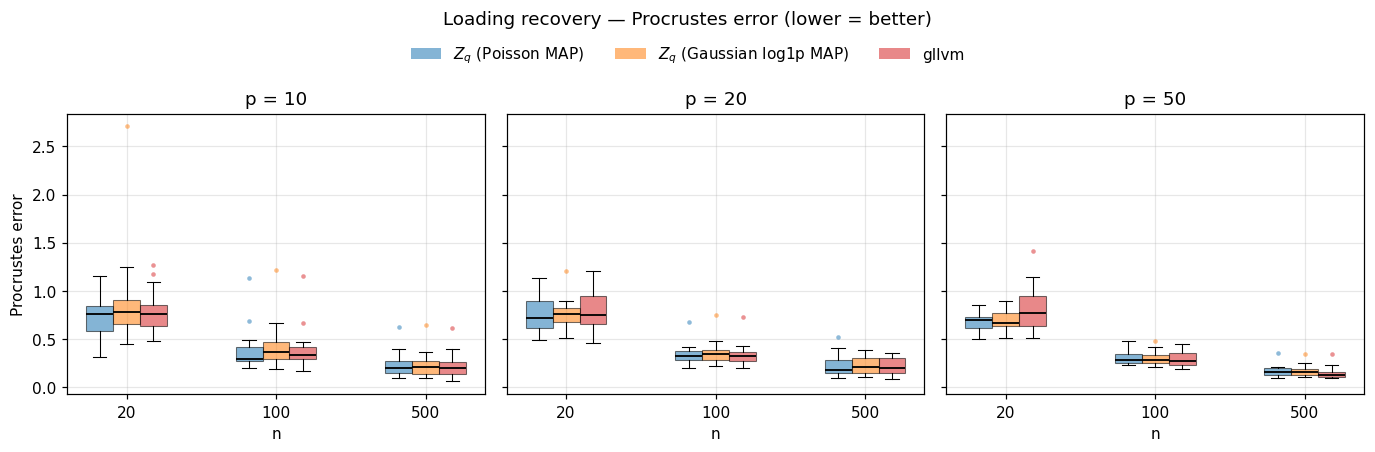

In [224]:
fits = (df[df.method != "true"]
        .drop_duplicates(["p", "n", "rep", "method"])
        [["p", "n", "rep", "method", "failed", "time_sec", "procrustes"]]
        .reset_index(drop=True))
ok = fits[fits.failed == 0.0].copy()

# methods: evenly spaced offsets within the n-tick slot
_n = len(METHODS)
_w = 0.18
_offsets = {m: (_w * (i - (_n-1)/2)) for i, m in enumerate(METHODS)}

def grouped_box(ax, sub, value):
    xticks = np.arange(len(N_VALS))
    for m in METHODS:
        data = [sub[(sub.n == n) & (sub.method == m)][value].dropna().values
                for n in N_VALS]
        bp = ax.boxplot(data, positions=xticks + _offsets[m], widths=_w,
                        patch_artist=True, manage_ticks=False, showfliers=True,
                        flierprops=dict(marker="o", markersize=3, alpha=0.5,
                                        markerfacecolor=MCOLOR[m], markeredgecolor="none"))
        for box in bp["boxes"]: box.set(facecolor=MCOLOR[m], alpha=0.55, edgecolor="k", lw=0.7)
        for med in bp["medians"]: med.set(color="black", lw=1.2)
        for w in bp["whiskers"] + bp["caps"]: w.set(color="black", lw=0.7)
    ax.set_xticks(xticks); ax.set_xticklabels(N_VALS)

fig, axes = plt.subplots(1, len(P_VALS), figsize=(4.2 * len(P_VALS), 3.8), sharey=True)
axes = np.atleast_1d(axes)
for ax, p in zip(axes, P_VALS):
    grouped_box(ax, ok[ok.p == p], "procrustes")
    ax.set_title(f"p = {p}"); ax.set_xlabel("n")
axes[0].set_ylabel("Procrustes error")
handles = [plt.Rectangle((0,0),1,1, fc=MCOLOR[m], alpha=0.55) for m in METHODS]
fig.legend(handles, [LABEL[m] for m in METHODS], loc="upper center", ncol=3,
           frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Loading recovery — Procrustes error (lower = better)", y=1.07)
fig.tight_layout(); plt.show()

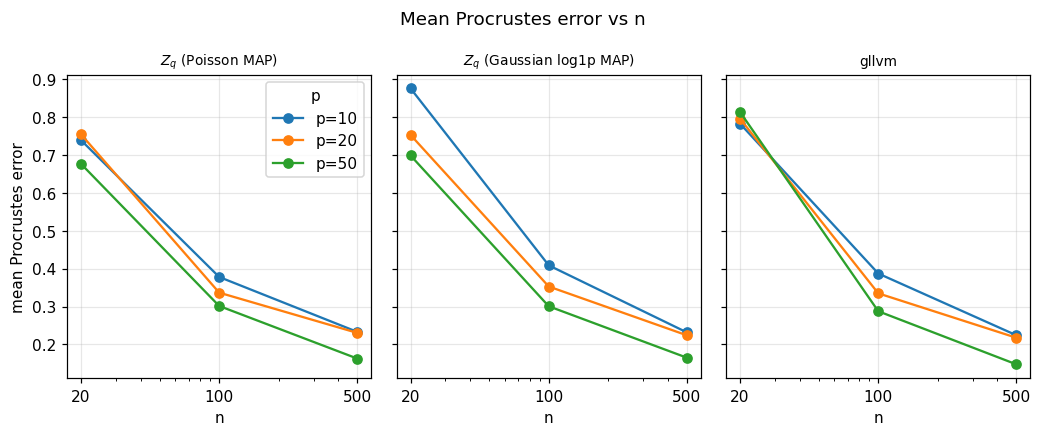

In [225]:
fig, axes = plt.subplots(1, len(METHODS), figsize=(3.2 * len(METHODS), 4), sharey=True)
axes = np.atleast_1d(axes)
mean_p = ok.groupby(["method", "p", "n"]).procrustes.mean().reset_index()
for ax, m in zip(axes, METHODS):
    for p in P_VALS:
        s = mean_p[(mean_p.method == m) & (mean_p.p == p)].sort_values("n")
        ax.plot(s.n, s.procrustes, "o-", label=f"p={p}")
    ax.set_xscale("log"); ax.set_xticks(N_VALS); ax.set_xticklabels(N_VALS)
    ax.set_title(LABEL[m], fontsize=9); ax.set_xlabel("n")
axes[0].set_ylabel("mean Procrustes error"); axes[0].legend(title="p")
fig.suptitle("Mean Procrustes error vs n"); fig.tight_layout(); plt.show()

## 1b · Tail risk & worst-case — the reliability story

The means above flatter neither method: the real difference is in the **spread
and the tail**. A (variational) MLE like gllvm is asymptotically efficient under
correct specification, so it tends to win the **median** by a hair — but it pays
with a **fat tail of catastrophic fits** (Procrustes ≫ 1, i.e. completely wrong),
especially when information is scarce. ZQE trades a sliver of median accuracy for
far lower variance and essentially no blow-ups.

Below: median (typical fit), 90th percentile, worst-case max, and the rate of
catastrophic fits (Procrustes > 0.5).

median                     mean                      p90           \
       zqe_pmap zqe_gmap  gllvm zqe_pmap zqe_gmap  gllvm zqe_pmap zqe_gmap   
p  n                                                                         
10 20     0.758    0.775  0.762    0.739    0.876  0.783    1.071    1.147   
   100    0.294    0.360  0.332    0.378    0.409  0.387    0.508    0.538   
   500    0.198    0.210  0.198    0.233    0.232  0.224    0.365    0.358   
20 20     0.721    0.759  0.745    0.755    0.753  0.796    0.950    0.871   
   100    0.323    0.349  0.321    0.337    0.353  0.335    0.406    0.447   
   500    0.176    0.207  0.199    0.230    0.224  0.218    0.386    0.318   
50 20     0.699    0.669  0.771    0.677    0.699  0.814    0.805    0.812   
   100    0.285    0.279  0.268    0.302    0.301  0.288    0.391    0.393   
   500    0.154    0.152  0.129    0.163    0.165  0.147    0.205    0.220   

                 worst                      std                  
        gllvm zqe_pmap zqe_gmap  gllvm zqe_pmap zqe_gmap  gllvm  
p  n                                                             
10 20   1.112    1.157    2.708  1.268    0.233    0.482  0.223  
   100  0.485    1.135    1.219  1.151    0.210    0.225  0.211  
   500  0.373    0.629    0.640  0.615    0.128    0.127  0.133  
20 20   1.049    1.134    1.203  1.210    0.175    0.155  0.208  
   100  0.416    0.674    0.748  0.724    0.099    0.116  0.111  
   500  0.330    0.518    0.383  0.354    0.112    0.080  0.084  
50 20   1.023    0.850    0.900  1.416    0.100    0.103  0.221  
   100  0.371    0.475    0.476  0.448    0.067    0.070  0.070  
   500  0.208    0.353    0.346  0.346    0.057    0.059  0.060

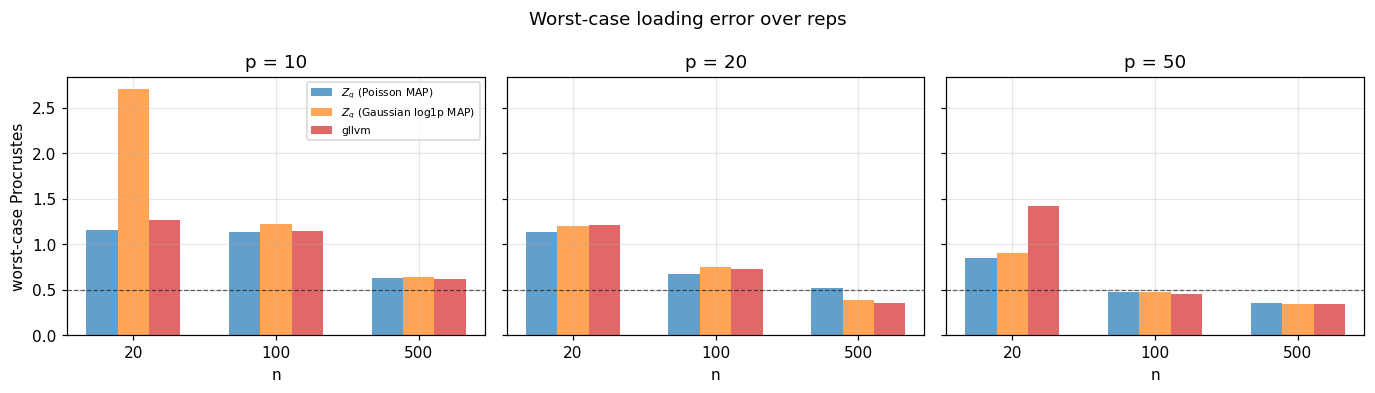

In [226]:
tail = (ok.groupby(["p", "n", "method"]).procrustes
        .agg(median="median", mean="mean", p90=lambda s: s.quantile(0.90),
             worst="max", std="std")
        .round(3))
_tail_wide = tail.unstack("method")
display(_tail_wide.reindex(columns=pd.MultiIndex.from_product(
    [["median","mean","p90","worst","std"], METHODS])))

fig, axes = plt.subplots(1, len(P_VALS), figsize=(4.2 * len(P_VALS), 3.6), sharey=True)
axes = np.atleast_1d(axes)
worst = ok.groupby(["p", "n", "method"]).procrustes.max().reset_index()
for ax, p in zip(axes, P_VALS):
    xt = np.arange(len(N_VALS))
    for k, m in enumerate(METHODS):
        s = worst[(worst.p == p) & (worst.method == m)].set_index("n").reindex(N_VALS)
        ax.bar(xt + (k - (len(METHODS)-1)/2) * 0.22, s.procrustes.values, width=0.22,
               color=MCOLOR[m], alpha=0.7, label=LABEL[m])
    ax.axhline(0.5, color="k", lw=0.8, ls="--", alpha=0.6)
    ax.set_xticks(xt); ax.set_xticklabels(N_VALS)
    ax.set_title(f"p = {p}"); ax.set_xlabel("n")
axes[0].set_ylabel("worst-case Procrustes"); axes[0].legend(fontsize=7)
fig.suptitle("Worst-case loading error over reps")
fig.tight_layout(); plt.show()

## 2 · Bias & variance of parameter recovery

Join each estimate to its rep's true value and form the **residual**
$r = \hat\theta - \theta$ (per element, after Procrustes rotation for loadings).
Pooling residuals over all elements and reps of a setting:

- **bias** $= \overline{r}$ (systematic over/under-estimation; $\approx 0$ is good),
- **variance / std** $= \mathrm{sd}(r)$ (estimator noise),
- **RMSE** $= \sqrt{\overline{r^2}}$ (combines both).

We report loadings ($W$) and intercepts ($b$) separately.

In [227]:
# residual = estimate - true, matched on (p,n,rep,param,i,j)
truth = (df[df.method == "true"]
         [["p", "n", "rep", "param", "i", "j", "value"]]
         .rename(columns={"value": "true"}))
est = df[df.method.isin(METHODS) & (df.failed == 0.0)]
res = est.merge(truth, on=["p", "n", "rep", "param", "i", "j"], how="left")
res["resid"] = res["value"] - res["true"]
# sign-corrected residual: negative = shrinkage, positive = expansion.
# avoids sign-cancellation when pooling positive and negative loadings.
res["abs_true"] = res["true"].abs()
res["signed_resid"] = np.sign(res["true"]) * res["resid"]

bv = (res.groupby(["param", "p", "n", "method"])
      .agg(bias=("signed_resid", "mean"),   # sign-corrected: negative = shrinkage
           std=("resid", "std"),
           rmse=("resid", lambda r: float(np.sqrt(np.mean(r**2)))))
      .round(4).reset_index())
print("Loadings (param='W') — bias = mean sign-corrected residual (negative = shrinkage):")
display(bv[bv.param == "W"].pivot_table(index=["p", "n"], columns="method",
                                        values=["bias", "std", "rmse"]))

Loadings (param='W') — bias = mean sign-corrected residual (negative = shrinkage):


bias                      rmse                       std           \
method   gllvm zqe_gmap zqe_pmap   gllvm zqe_gmap zqe_pmap   gllvm zqe_gmap   
p  n                                                                          
10 20  -0.0370   0.0027  -0.0235  0.3755   0.4737   0.3541  0.3754   0.4728   
   100 -0.0346  -0.0225  -0.0299  0.1848   0.1929   0.1806  0.1850   0.1932   
   500 -0.0247  -0.0184  -0.0206  0.1166   0.1167   0.1185  0.1166   0.1166   
20 20  -0.0015  -0.0088  -0.0212  0.4057   0.3787   0.3833  0.4057   0.3780   
   100 -0.0097  -0.0063  -0.0071  0.1706   0.1797   0.1714  0.1707   0.1798   
   500 -0.0112  -0.0096  -0.0152  0.1154   0.1185   0.1254  0.1155   0.1185   
50 20   0.0009  -0.0066  -0.0149  0.4291   0.3555   0.3440  0.4292   0.3555   
   100 -0.0040  -0.0033  -0.0072  0.1480   0.1545   0.1545  0.1480   0.1545   
   500 -0.0030  -0.0041  -0.0049  0.0788   0.0866   0.0864  0.0788   0.0867   

                 
method zqe_pmap  
p  n             
10 20    0.3534  
   100   0.1808  
   500   0.1184  
20 20    0.3822  
   100   0.1715  
   500   0.1252  
50 20    0.3440  
   100   0.1545  
   500   0.0864

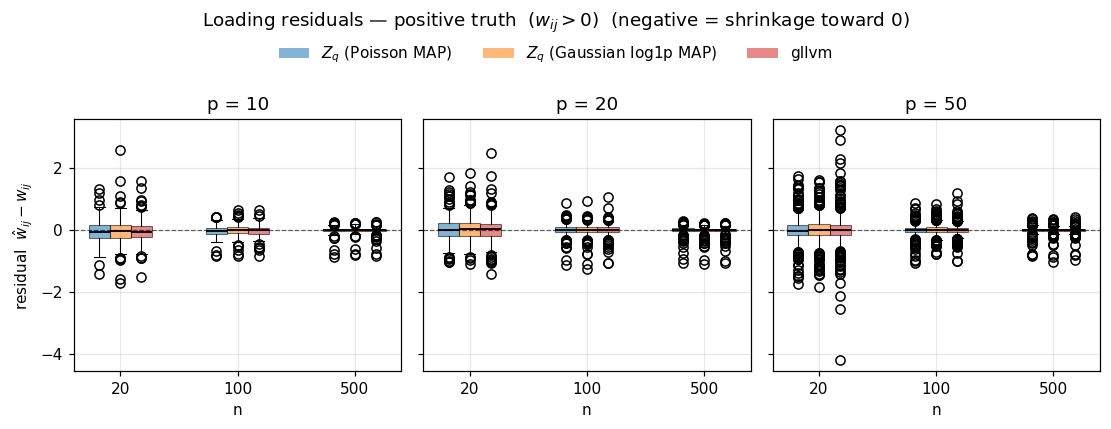

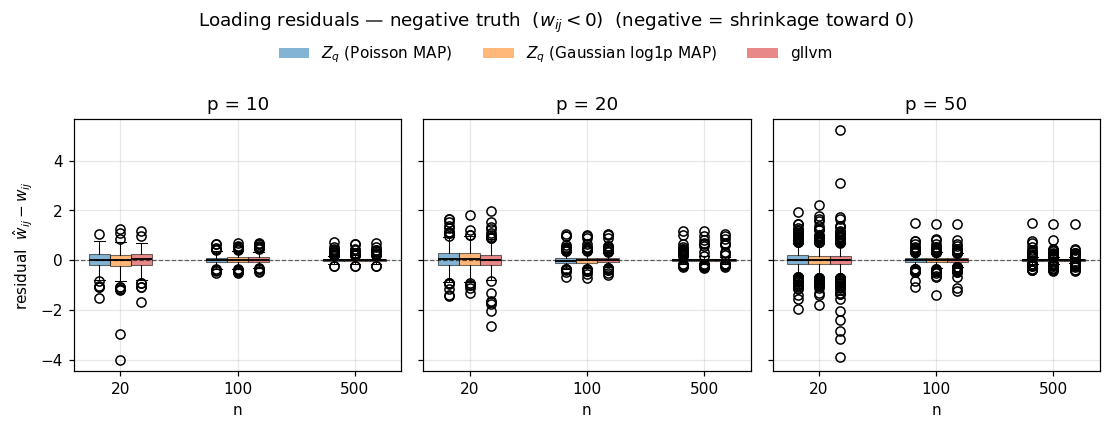

In [228]:
# Loading residuals SPLIT BY SIGN OF TRUE LOADING.
# Positive truth: shrinkage shows as negative residual (est < true).
# Negative truth: shrinkage shows as positive residual (est > true, i.e. closer to 0).
# Pooling the two would cancel — hence separate panels.
W_res = res[res.param == "W"].copy()
_n, _w = len(METHODS), 0.18

for sign_label, sign_mask in [("positive truth  ($w_{ij} > 0$)", W_res.true > 0),
                               ("negative truth  ($w_{ij} < 0$)", W_res.true < 0)]:
    sub_all = W_res[sign_mask]
    fig, axes = plt.subplots(1, len(P_VALS), figsize=(3.4 * len(P_VALS), 3.6), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, p in zip(axes, P_VALS):
        xticks = np.arange(len(N_VALS))
        for k, m in enumerate(METHODS):
            off = _w * (k - (_n - 1) / 2)
            data = [sub_all[(sub_all.p == p) & (sub_all.n == n) & (sub_all.method == m)]
                    .resid.dropna().values for n in N_VALS]
            bp = ax.boxplot(data, positions=xticks + off, widths=_w,
                            patch_artist=True, manage_ticks=False, showfliers=True)
            for box in bp["boxes"]:   box.set(facecolor=MCOLOR[m], alpha=0.55, edgecolor="k", lw=0.7)
            for med in bp["medians"]: med.set(color="black", lw=1.2)
            for w in bp["whiskers"] + bp["caps"]: w.set(color="black", lw=0.7)
        ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.6)
        ax.set_xticks(xticks); ax.set_xticklabels(N_VALS)
        ax.set_title(f"p = {p}"); ax.set_xlabel("n")
    axes[0].set_ylabel(r"residual  $\hat w_{ij} - w_{ij}$")
    handles = [plt.Rectangle((0,0),1,1, fc=MCOLOR[m], alpha=0.55) for m in METHODS]
    fig.legend(handles, [LABEL[m] for m in METHODS], loc="upper center", ncol=3,
               frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"Loading residuals — {sign_label}  (negative = shrinkage toward 0)", y=1.07)
    fig.tight_layout(); plt.show()

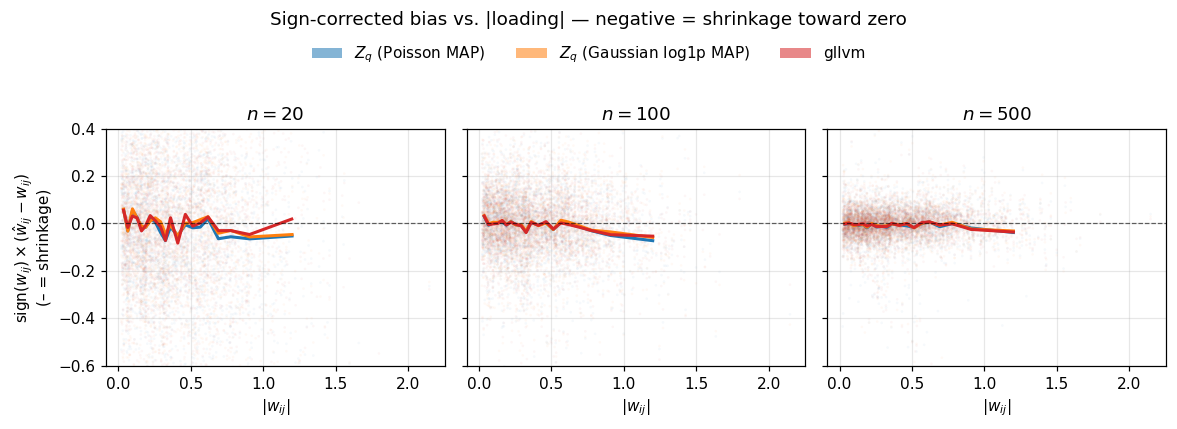

In [229]:
def binned_mean(x, y, nbins=20):
    order = np.argsort(x)
    x, y = x[order], y[order]
    edges = np.quantile(x, np.linspace(0, 1, nbins + 1))
    idx = np.clip(np.digitize(x, edges[1:-1]), 0, nbins - 1)
    bx = np.array([x[idx == b].mean() for b in range(nbins) if (idx == b).any()])
    by = np.array([y[idx == b].mean() for b in range(nbins) if (idx == b).any()])
    return bx, by

# Sign-corrected bias: sign(W_true)×(W_est−W_true) vs |W_true|.
# Negative = shrinkage toward zero; positive = expansion.
W_res_sc = res[(res.param == "W") & (res.abs_true > 0.02)]
fig, axes = plt.subplots(1, len(N_VALS), figsize=(3.6 * len(N_VALS), 3.6),
                         sharey=True, sharex=True)
axes = np.atleast_1d(axes)
for ax, n in zip(axes, N_VALS):
    sub = W_res_sc[W_res_sc.n == n]
    for m in METHODS:
        d = sub[sub.method == m]
        x = d["abs_true"].to_numpy(float)
        y = d["signed_resid"].to_numpy(float)
        ax.scatter(x, y, s=3, alpha=0.04, color=MCOLOR[m], edgecolors="none")
        bx, by = binned_mean(x, y)
        ax.plot(bx, by, "-", color=MCOLOR[m], lw=2.0, label=LABEL[m])
    ax.axhline(0.0, color="k", lw=0.8, ls="--", alpha=0.6)
    ax.set_ylim(-0.6, 0.4)
    ax.set_title(f"$n = {n}$"); ax.set_xlabel(r"$|w_{ij}|$")
axes[0].set_ylabel(r"sign$(w_{ij})\times(\hat w_{ij}-w_{ij})$" + "\n(– = shrinkage)")
handles = [plt.Rectangle((0,0),1,1, fc=MCOLOR[m], alpha=0.55) for m in METHODS]
fig.legend(handles, [LABEL[m] for m in METHODS], loc="upper center", ncol=3,
           frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Sign-corrected bias vs. |loading| — negative = shrinkage toward zero", y=1.07)
fig.tight_layout(rect=(0,0,1,0.96)); plt.show()

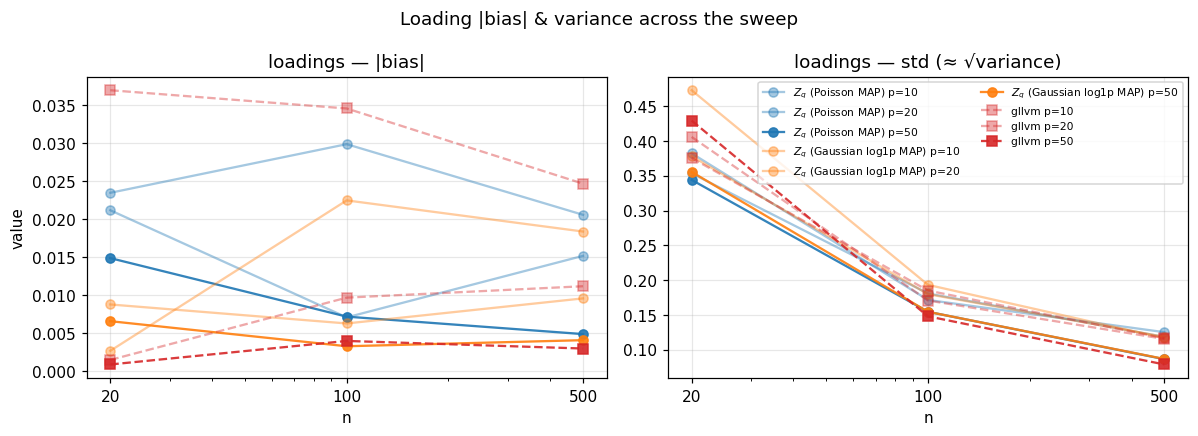

In [230]:
# |bias| and std of loadings vs n, lines per p (one panel each).
W_bv = bv[bv.param == "W"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (col, lab) in zip(axes, [("bias", "|bias|"), ("std", "std (≈ √variance)")]):
    for m in METHODS:
        for p in P_VALS:
            s = W_bv[(W_bv.method == m) & (W_bv.p == p)].sort_values("n")
            y = s[col].abs() if col == "bias" else s[col]
            ax.plot(s.n, y, "o-" if m.startswith("zqe") else "s--",
                    color=MCOLOR[m], alpha=0.4 + 0.5 * (p == max(P_VALS)),
                    label=f"{LABEL[m]} p={p}")
    ax.set_xscale("log"); ax.set_xticks(N_VALS); ax.set_xticklabels(N_VALS)
    ax.set_xlabel("n"); ax.set_title(f"loadings — {lab}")
axes[0].set_ylabel("value")
axes[1].legend(fontsize=7, ncol=2)
fig.suptitle("Loading |bias| & variance across the sweep")
fig.tight_layout(); plt.show()

### Intercepts ($b$)

In [231]:
display(bv[bv.param == "b"].pivot_table(index=["p", "n"], columns="method",
                                       values=["bias", "std", "rmse"]))

bias                      rmse                       std           \
method   gllvm zqe_gmap zqe_pmap   gllvm zqe_gmap zqe_pmap   gllvm zqe_gmap   
p  n                                                                          
10 20   0.1283   0.1783   0.1123  0.4577   0.7798   0.4289  0.4437   0.7658   
   100  0.0156   0.0195   0.0154  0.1557   0.1602   0.1600  0.1549   0.1591   
   500  0.0022   0.0058   0.0054  0.0734   0.0779   0.0776  0.0733   0.0774   
20 20   0.1230   0.0937   0.0941  0.5940   0.5065   0.5103  0.5739   0.4947   
   100  0.0208   0.0206   0.0185  0.1817   0.1865   0.1854  0.1790   0.1839   
   500  0.0059   0.0060   0.0050  0.0702   0.0727   0.0718  0.0700   0.0725   
50 20   0.2736   0.0891   0.0850  4.0385   0.5446   0.5354  4.0272   0.5300   
   100  0.0202   0.0184   0.0164  0.1942   0.1944   0.1849  0.1928   0.1934   
   500  0.0057   0.0054   0.0049  0.0729   0.0753   0.0751  0.0725   0.0749   

                 
method zqe_pmap  
p  n             
10 20    0.4207  
   100   0.1596  
   500   0.0773  
20 20    0.4995  
   100   0.1832  
   500   0.0717  
50 20    0.5227  
   100   0.1842  
   500   0.0748

## 3 · Fit time

Wall-clock seconds per fit (mean over reps), log–log vs $p$, one line per $n$.

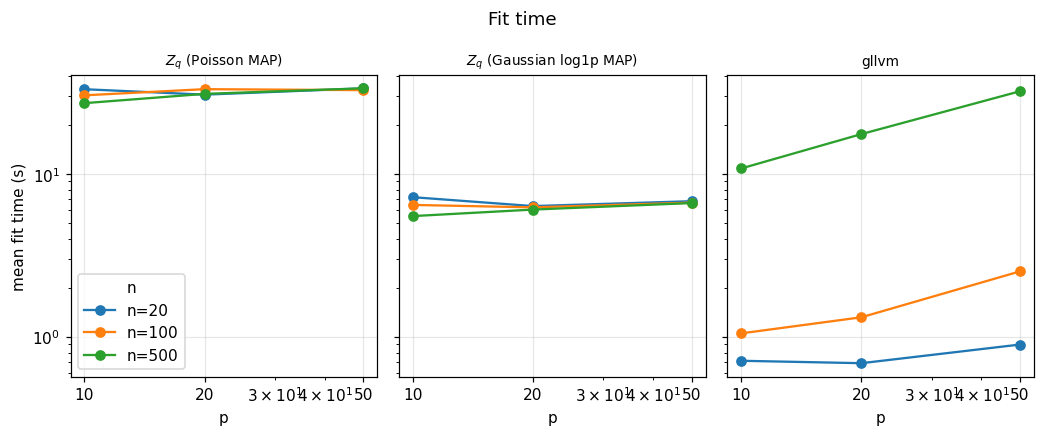

In [232]:
fig, axes = plt.subplots(1, len(METHODS), figsize=(3.2 * len(METHODS), 4), sharey=True)
axes = np.atleast_1d(axes)
mean_t = ok.groupby(["method", "p", "n"]).time_sec.mean().reset_index()
for ax, m in zip(axes, METHODS):
    for n in N_VALS:
        s = mean_t[(mean_t.method == m) & (mean_t.n == n)].sort_values("p")
        ax.plot(s.p, s.time_sec, "o-", label=f"n={n}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(P_VALS); ax.set_xticklabels(P_VALS)
    ax.set_title(LABEL[m], fontsize=9); ax.set_xlabel("p")
axes[0].set_ylabel("mean fit time (s)"); axes[0].legend(title="n")
fig.suptitle("Fit time"); fig.tight_layout(); plt.show()

## Takeaways

Under **correct specification** the (variational) MLE is asymptotically efficient, so gllvm edges the **median** Procrustes in the comfortable regime — expected, and not a race ZQE can win. ZQE's turf is the rest of the table: **much lower variance, no catastrophic blow-ups, and a flat ~6 s fit time** vs gllvm's n-scaling cost (25×+ at n=500). The head-to-head means below, read alongside the tail-risk panel, tell that story.

In [233]:
head = (ok.groupby(["p", "n", "method"])
        .agg(median=("procrustes","median"), mean=("procrustes","mean"),
             time_s=("time_sec","mean"))
        .round(3).reset_index()
        .pivot_table(index=["p","n"], columns="method", values=["median","mean","time_s"]))
# pivot_table names the column levels (None, "method"); strip names so reindex works
head.columns.names = [None, None]
head = head.reindex(columns=pd.MultiIndex.from_product([["median","mean","time_s"], METHODS]))
head

median                     mean                   time_s           \
       zqe_pmap zqe_gmap  gllvm zqe_pmap zqe_gmap  gllvm zqe_pmap zqe_gmap   
p  n                                                                         
10 20     0.758    0.775  0.762    0.739    0.876  0.783   33.177    7.205   
   100    0.294    0.360  0.332    0.378    0.409  0.387   30.432    6.457   
   500    0.198    0.210  0.198    0.233    0.232  0.224   27.243    5.514   
20 20     0.721    0.759  0.745    0.755    0.753  0.796   30.727    6.353   
   100    0.323    0.349  0.321    0.337    0.353  0.335   33.204    6.240   
   500    0.176    0.207  0.199    0.230    0.224  0.218   31.062    6.046   
50 20     0.699    0.669  0.771    0.677    0.699  0.814   33.588    6.807   
   100    0.285    0.279  0.268    0.302    0.301  0.288   32.753    6.671   
   500    0.154    0.152  0.129    0.163    0.165  0.147   33.608    6.631   

                
         gllvm  
p  n            
10 20    0.712  
   100   1.050  
   500  10.824  
20 20    0.688  
   100   1.318  
   500  17.588  
50 20    0.896  
   100   2.524  
   500  32.249